# Step 1: Import Libraries. #

In [43]:
#-- Core and Utilities. --#
import os, sys, glob
import numpy as np
import pandas as pd
#-- Data Visualization. --#
import seaborn as sns
import matplotlib.pyplot as plt
#-- Machine Learning and Evaluation. --#
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
#-- Deep Learning (Tensorflow/Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout)
from tensorflow.keras.utils import to_categorical

# Step 2: Import files. #

In [44]:
train_dir = '../Datasets/Train/Numbers'
test_dir = '../Datasets/Test/Numbers'
#-- Check train_dir exists or not. --#
if not os.path.exists(train_dir):
    print(f"The {train_dir} does not exist! Please check again.")
else:
    print(f"The {train_dir} exists")
    #-- Check test_dir exists on not. --#
    if not os.path.exists(test_dir):
        print(f"The {test_dir} does not exit! Please check again.")
    else:
        print(f"The {test_dir} exists,")

The ../Datasets/Train/Numbers exists
The ../Datasets/Test/Numbers exists,


In [45]:
train_csv_files = glob.glob(os.path.join(train_dir, "*.csv"))
print("-" * 56)
print("Import Files")
for file in train_csv_files:
    print(f"Found files:{file}")

--------------------------------------------------------
Import Files
Found files:../Datasets/Train/Numbers\mnist_train_1.csv
Found files:../Datasets/Train/Numbers\mnist_train_2.csv
Found files:../Datasets/Train/Numbers\mnist_train_3.csv
Found files:../Datasets/Train/Numbers\mnist_train_4.csv
Found files:../Datasets/Train/Numbers\mnist_train_5.csv
Found files:../Datasets/Train/Numbers\mnist_train_6.csv


In [46]:
test_csv_files = glob.glob(os.path.join(test_dir, "*.csv"))
print("-" * 56)
print("Import Files")
for file in test_csv_files:
    print(f"Found files:{file}")

--------------------------------------------------------
Import Files
Found files:../Datasets/Test/Numbers\mnist_test.csv


# Step 3: Data Processing #

In [47]:
#-- Combine all .csv files into one Dataframe. --#
print("Combinig data processing.......")
train_df_list = [pd.read_csv(file) for file in train_csv_files]
combined_df = pd.concat(train_df_list, ignore_index=True)
#-- Split Features and Labels from combined_df. --#
print("Split Features and Labels from combined_df......")
X = combined_df.iloc[:, 1:].values
y = combined_df.iloc[:, 0].values
#-- Split train into Train set and Validation set (80%, 20%). --#
print("Split train datasets into Train and Validation....")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
#-- Normalizaion. --#
print("Normalization step.....")
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
#-- Reshape steps. --#
print("Reshape steps......")
image_size = int(np.sqrt(X_train.shape[1]))
X_train = X_train.reshape(-1, image_size, image_size, 1)
X_val = X_val.reshape(-1, image_size, image_size, 1)
#-- One-Hot Encoding Labels. --#
y_train = to_categorical(y_train, num_classes=10)
y_val = to_categorical(y_val, num_classes=10)
#-- Print result. --+
print("-" * 56)
print(f"Size of X_train: {X_train.shape}")
print(f"Size of y_train: {y_train.shape}")
print(f"Size of X_val:   {X_val.shape}")
print(f"Size of y_val:   {y_val.shape}")
print("Data Processing Completed")


Combinig data processing.......
Split Features and Labels from combined_df......
Split train datasets into Train and Validation....
Normalization step.....
Reshape steps......
--------------------------------------------------------
Size of X_train: (48000, 28, 28, 1)
Size of y_train: (48000, 10)
Size of X_val:   (12000, 28, 28, 1)
Size of y_val:   (12000, 10)
Data Processing Completed


# Step 4: Build conv2d layer... #


In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

model = Sequential()
model.add(Conv2D(
    filters=32,                  #-- Number of filters (feature maps). --#
    kernel_size=(3, 3),          #-- Size of the scanning kernel/filter (3x3). --#
    activation='relu',           #-- Activation function for non-linearity. --#
    input_shape=(28, 28, 1)      #-- Input image dimensions (Height: 28, Width: 28, Channels: 1 - grayscale). --#
))
print("Successfully added the first Conv2D layer!")

Successfully added the first Conv2D layer!


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- SAMPLE INFORMATION ---
Output (True Label): 5
Input Raw Shape (Pixels): (784,)
Input Reshape for CNN: (28, 28, 1)


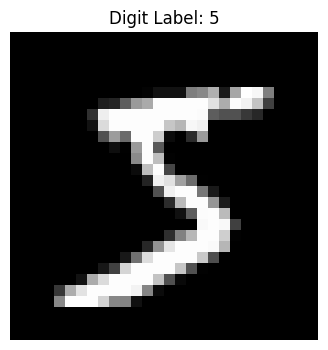

In [57]:
sample_row = combined_df.iloc[0]
sample_label = sample_row.iloc[0]
sample_pixels = sample_row.iloc[1:].values

image_size = int(np.sqrt(len(sample_pixels)))
sample_image = sample_pixels.reshape(image_size, image_size)

print(f"--- SAMPLE INFORMATION ---")
print(f"Output (True Label): {sample_label}")
print(f"Input Raw Shape (Pixels): {sample_pixels.shape}")
print(f"Input Reshape for CNN: ({image_size}, {image_size}, 1)")

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap='gray')
plt.title(f"Digit Label: {sample_label}")
plt.axis('off')
plt.show()

In [58]:
#-- Extract Feature Maps. --#
#-- Get a sample image from the validation set (X_val[0]) --#
sample_img = X_val[0:1] 
#-- Pass the sample image directly through the first Conv2D layer to get feature maps --#
conv_layer = model.layers[0]
feature_maps = conv_layer(sample_img)
print("Feature maps extracted successfully!")

Feature maps extracted successfully!


The ../Figures exists


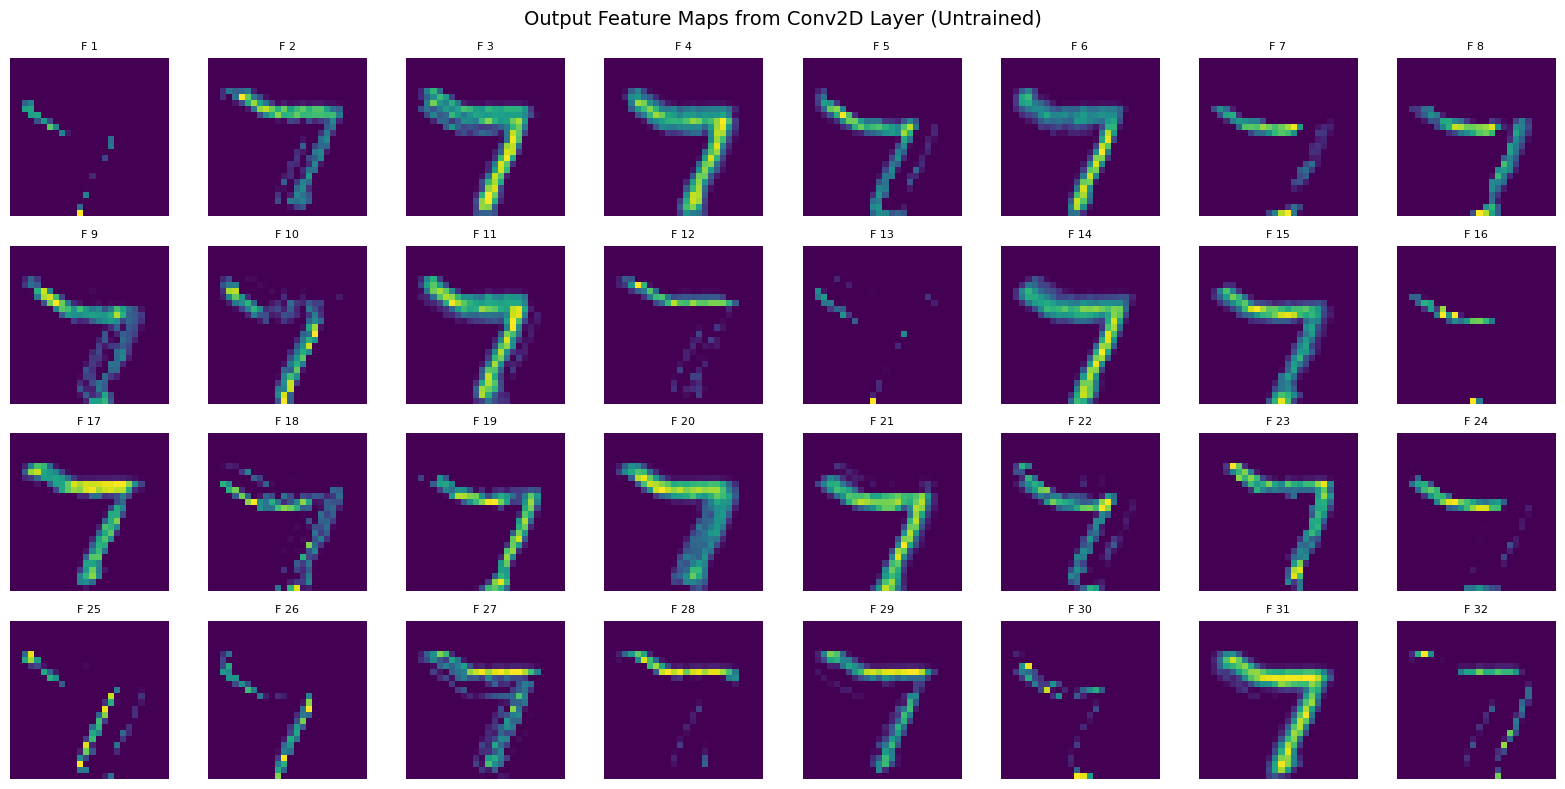

Saved successfully at: ../Figures\Digit_Conv2d_Output.png


In [59]:
fig_dir = '../Figures'
if not os.path.exists(fig_dir):
    print(f"The {fig_dir} does not exist! Please check again")
else:
    print(f"The {fig_dir} exists")
    plt.figure(figsize=(16, 8))
    for i in range(32):
        plt.subplot(4, 8, i + 1)
        f_map = feature_maps[0, :, :, i]
        plt.imshow(f_map, cmap='viridis')
        plt.title(f"F {i+1}", fontsize=8)
        plt.axis('off')

    plt.suptitle("Output Feature Maps from Conv2D Layer (Untrained)", fontsize=14)
    plt.tight_layout()

    file_path = os.path.join(fig_dir, 'Digit_Conv2d_Output.png')
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved successfully at: {file_path}")

# Step 5: Build Maxpooling layer. #

In [60]:
model.add(MaxPooling2D(
    pool_size=(2, 2),  #-- Window size for pooling (2x2) --#
    strides=2          #-- Move window by 2 pixels --#
))

print("Successfully added the MaxPooling2D layer!")

Successfully added the MaxPooling2D layer!


In [61]:
#-- Extract Pooled Feature Maps. --#
conv_output = model.layers[0](sample_img)
pool_output = model.layers[1](conv_output)

print("Pooled feature maps extracted successfully!")

Pooled feature maps extracted successfully!


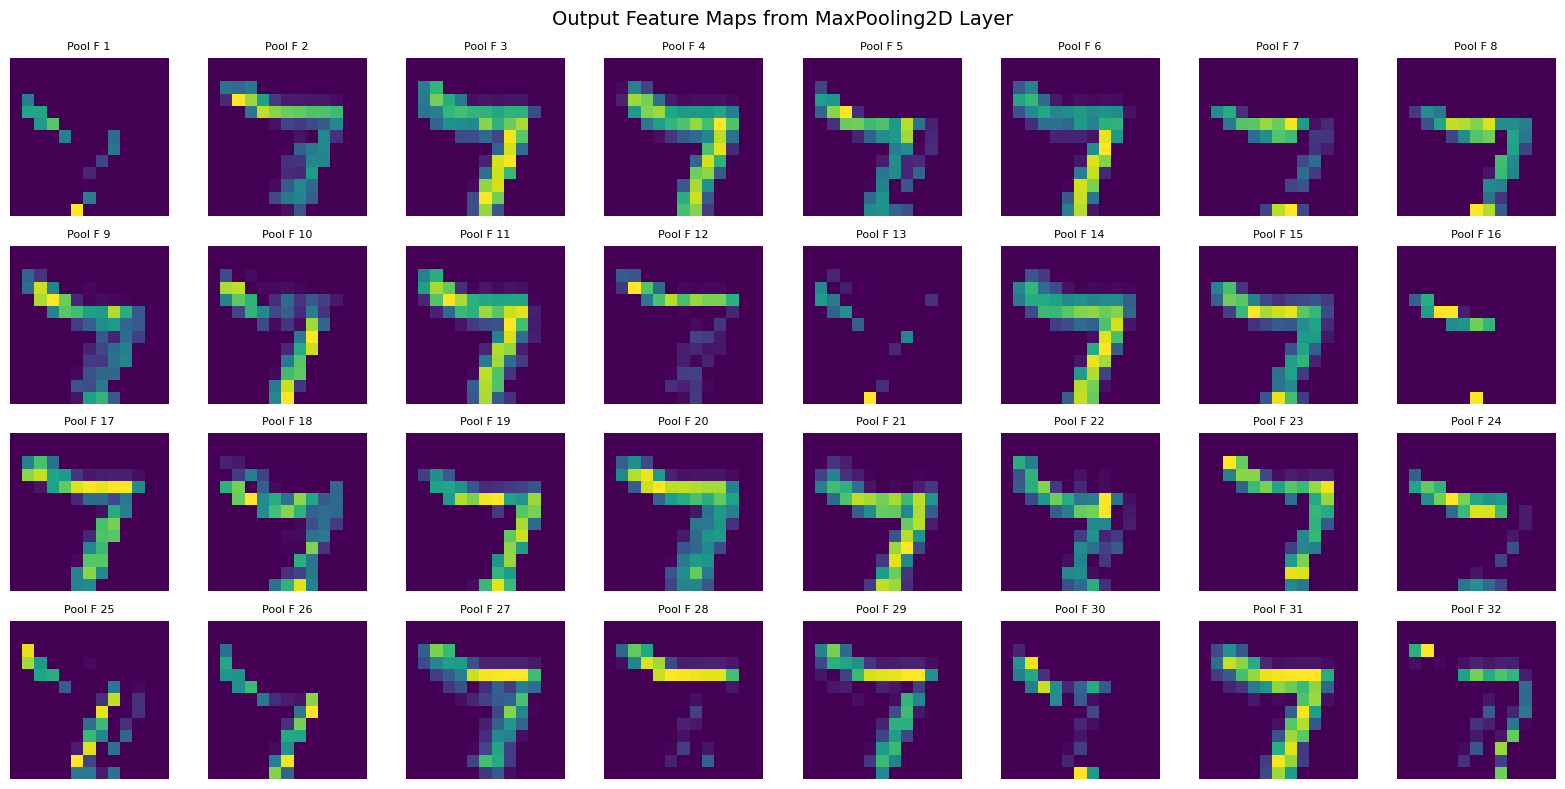

Saved successfully at: ../Figures\Digit_MaxPooling_Output.png


In [62]:
fig_dir = '../Figures'
plt.figure(figsize=(16, 8))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    p_map = pool_output[0, :, :, i]
    plt.imshow(p_map, cmap='viridis')
    plt.title(f"Pool F {i+1}", fontsize=8)
    plt.axis('off')

plt.suptitle("Output Feature Maps from MaxPooling2D Layer", fontsize=14)
plt.tight_layout()

file_path = os.path.join(fig_dir, 'Digit_MaxPooling_Output.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved successfully at: {file_path}")

# Step 6: Build Flatten Layer. #

In [63]:
from tensorflow.keras.layers import Flatten
#-- Add a Flatten layer to convert 3D feature maps into a 1D vector --#
model.add(Flatten())
print("Successfully added the Flatten layer!")

Successfully added the Flatten layer!


In [64]:
#-- Get a sample image from the validation set --#
sample_img = X_val[0:1]
#-- Pass the sample through Conv2D, MaxPooling2D, and Flatten layers --#
x = model.layers[0](sample_img)
x = model.layers[1](x)
flatten_output = model.layers[2](x)
print(f"Original image shape: {sample_img.shape}")
print(f"Flattened output shape: {flatten_output.shape}")

Original image shape: (1, 28, 28, 1)
Flattened output shape: (1, 5408)


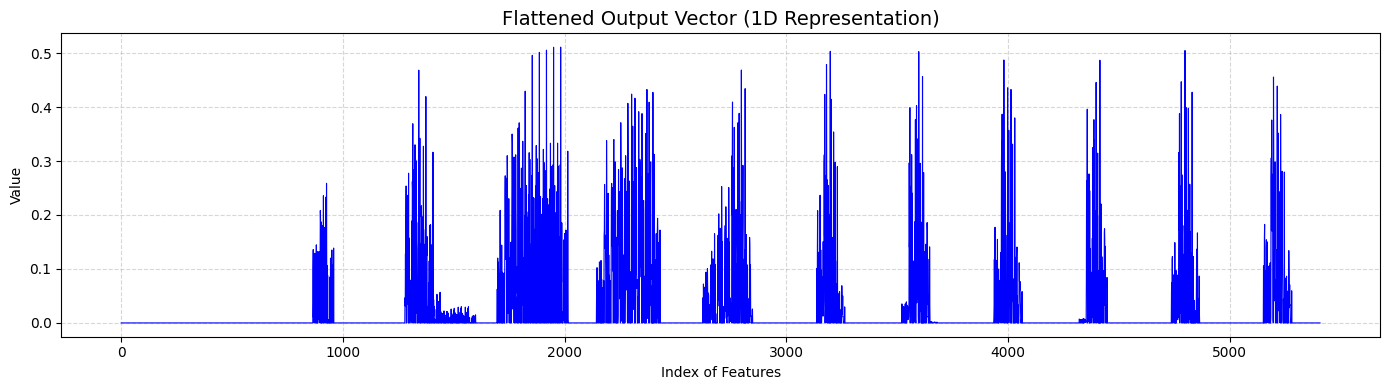

Saved successfully at: ../Figures\Digit_Flatten_Output.png


In [65]:
fig_dir = '../Figures'
plt.figure(figsize=(14, 4))
plt.plot(flatten_output.numpy()[0], color='blue', linewidth=0.8)
plt.title("Flattened Output Vector (1D Representation)", fontsize=14)
plt.xlabel("Index of Features", fontsize=10)
plt.ylabel("Value", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

file_path = os.path.join(fig_dir, 'Digit_Flatten_Output.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved successfully at: {file_path}")

# Step 7: Dense Layer... #

In [66]:
from tensorflow.keras.layers import Dense, Dropout
#-- Add a Hidden Dense Layer with ReLU activation --#
model.add(Dense(units=128, activation='relu'))
#-- Add a Dropout layer to prevent overfitting --#
model.add(Dropout(0.5))
#-- Add the Output Dense Layer with Softmax activation (10 classes for digits 0-9) --#
model.add(Dense(units=10, activation='softmax'))
print("Successfully added Dense and Output layers!")

Successfully added Dense and Output layers!


In [67]:
#-- Print the complete architecture of the CNN model --#
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

# Step 8: Connect to combine model. #

In [69]:
#-- Build the complete CNN model --#
# 1. Convolutional Layer (Extract features)
# 2. MaxPooling Layer (Downsample)
# 3. Flatten Layer (Convert 3D feature maps to 1D vector)
# 4. Hidden Dense Layer (Learn complex patterns)
# 5. Dropout Layer (Prevent overfitting)
# 6. Output Dense Layer (10 classes for digits 0-9)

model = Sequential([Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)), 
        MaxPooling2D(pool_size=(2, 2), strides=2),
        Flatten(),
        Dense(units=128, activation='relu'),
        Dropout(0.5),    
        Dense(units=10, activation='softmax')])
#-- Compile the model --#
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
#-- Print model architecture summary --#
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

# Step 9: Train Model #

In [70]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
#-- Configure EarlyStopping: Automatically stop when validation loss stops improving. --#
early_stopping = EarlyStopping(
    monitor='val_loss',       # Monitor the validation loss
    patience=10,              # Wait for 10 epochs with no improvement before stopping
    restore_best_weights=True # Automatically rollback and keep weights from the best epoch
)
#-- Automatically save the best model weights during training. --#
checkpoint = ModelCheckpoint(
    'best_model.keras', 
    monitor='val_loss', 
    save_best_only=True
)
#-- Train with a large maximum epoch cap, but let it stop naturally when finished. --#
history = model.fit(
    X_train, y_train,
    epochs=1000,              # Set a high ceiling so it never cuts short prematurely
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.8344 - loss: 0.5412 - val_accuracy: 0.9714 - val_loss: 0.0953
Epoch 2/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9631 - loss: 0.1272 - val_accuracy: 0.9797 - val_loss: 0.0676
Epoch 3/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9706 - loss: 0.0941 - val_accuracy: 0.9825 - val_loss: 0.0585
Epoch 4/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9785 - loss: 0.0712 - val_accuracy: 0.9851 - val_loss: 0.0527
Epoch 5/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.9789 - loss: 0.0659 - val_accuracy: 0.9859 - val_loss: 0.0490
Epoch 6/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9842 - loss: 0.0512 - val_accuracy: 0.9875 - val_loss: 0.0464
Epoch 7/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9862 - loss: 0.0461 - val_accuracy: 0.9878 - val_loss: 0.0446
Epoch 8/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9865 -

# Step 10: Evalaution Model #

In [71]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
#-- Predict on the validation set to get labels. --#
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
#-- Handle y_val if it is in One-Hot Encoding format. --#
if len(y_val.shape) > 1 and y_val.shape[1] > 1:
    y_true = np.argmax(y_val, axis=1)
else:
    y_true = y_val
#-- Calculate detailed Precision, Recall, and F1-score. --#
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print("=== EVALUATION METRICS ON VALIDATION SET ===")
print(f"Final Accuracy:   {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Loss:       {history.history['val_loss'][-1]:.4f}")
print(f"Precision (Wgt):  {precision:.4f}")
print(f"Recall (Wgt):     {recall:.4f}")
print(f"F1-Score (Wgt):   {f1:.4f}\n")

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
=== EVALUATION METRICS ON VALIDATION SET ===
Final Accuracy:   0.9898
Final Loss:       0.0523
Precision (Wgt):  0.9888
Recall (Wgt):     0.9888
F1-Score (Wgt):   0.9887



In [72]:
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1175
           1       0.99      1.00      1.00      1322
           2       0.98      0.99      0.99      1174
           3       0.99      0.99      0.99      1219
           4       0.99      0.99      0.99      1176
           5       0.99      0.98      0.99      1104
           6       0.99      0.99      0.99      1177
           7       0.99      0.99      0.99      1299
           8       0.98      0.98      0.98      1160
           9       0.99      0.98      0.98      1194

    accuracy                           0.99     12000
   macro avg       0.99      0.99      0.99     12000
weighted avg       0.99      0.99      0.99     12000



In [75]:
print("=== CONFUSION MATRIX ===")
conf_matrix = confusion_matrix(y_true, y_pred)
print(conf_matrix)

=== CONFUSION MATRIX ===
[[1160    0    3    0    1    1    7    0    1    2]
 [   0 1316    2    1    1    0    1    0    1    0]
 [   0    2 1166    1    0    0    0    2    2    1]
 [   0    0    5 1204    0    4    1    1    2    2]
 [   1    0    0    0 1167    0    1    1    0    6]
 [   2    1    1    5    1 1086    2    0    6    0]
 [   1    0    0    0    1    2 1170    0    3    0]
 [   1    3    7    2    1    0    0 1281    4    0]
 [   2    0    2    1    2    1    3    3 1142    4]
 [   1    1    1    1    8    1    1    6    1 1173]]


Saved: d:\University\May_2026\Group1_ThemeB_HandwrittenNumberRecognitionSystem\Figures\Training_and_Validation_Loss_Curve.png


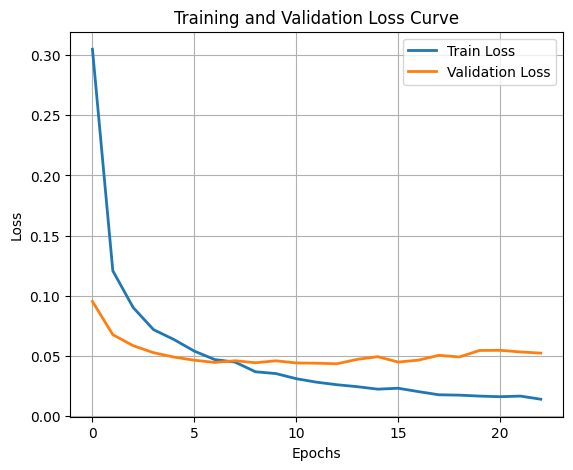

In [79]:
#-- Plot Training & Validation Curves (Loss & Accuracy). --#
plt.figure(figsize=(14, 5))
#-- Loss Curve. --#
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
figure_path = '../Figures/Training_and_Validation_Loss_Curve.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.abspath(figure_path)}")

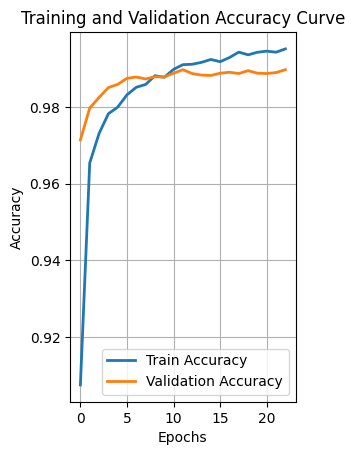

Saved: d:\University\May_2026\Group1_ThemeB_HandwrittenNumberRecognitionSystem\Figures\Training_and_Validation_Accuracy_Curve.png


<Figure size 640x480 with 0 Axes>

In [80]:
#-- Accuracy Curve. --#
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Training and Validation Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()
figure_path = '../Figures/Training_and_Validation_Accuracy_Curve.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
print(f"Saved: {os.path.abspath(figure_path)}")

# Step 11: Testing #

In [84]:
test = pd.read_csv('../Datasets/Test/Numbers/mnist_test.csv')
display(test)
if test.shape[1] == 785:
    y_test_true = test.iloc[:, 0].values
    X_test_raw = test.iloc[:, 1:].values
else: 
    y_test_true = None
    X_test_raw = test.values
X_test = X_test_raw.astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [85]:
y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

if y_test_true is not None:
    from sklearn.metrics import accuracy_score, classification_report
    
    acc = accuracy_score(y_test_true, y_test_pred)
    print(f"🎯 Test Accuracy: {acc * 100:.2f}%\n")
    
    print("Classification Report:")
    print(classification_report(y_test_true, y_test_pred))
else:
    print("The test file does not contain labels; this is a pure prediction dataset.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
🎯 Test Accuracy: 98.78%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.98      0.99      0.98      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



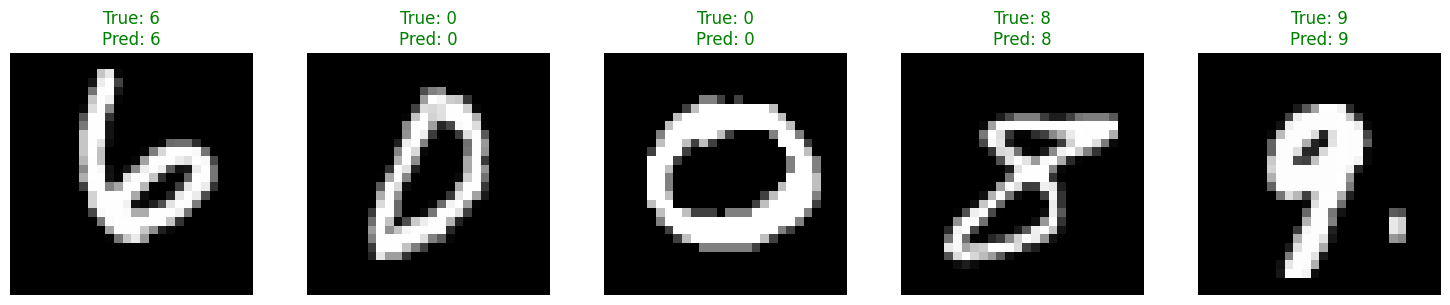

In [89]:
num_samples = 5
plt.figure(figsize=(15, 3))

for i in range(num_samples):
    idx = np.random.randint(0, len(X_test))
    
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    
    pred_label = y_test_pred[idx]
    
    if y_test_true is not None:
        true_label = y_test_true[idx]
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    else:
        plt.title(f"Pred: {pred_label}", color='blue')
        
    plt.axis('off')

plt.tight_layout()
plt.show()

# Step 12: Export to model #

In [90]:
model_folder = '../Models'
model_path = os.path.join(model_folder, 'digit_cnn_model.keras')
model.save(model_path)
print(f"✅ Model successfully saved to: {model_path}")

✅ Model successfully saved to: ../Models\digit_cnn_model.keras
